In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt

import numpy as np
import hmm
import emission_model
import pandas as pd
import matplotlib.pyplot as plt

from utils import Student, plot_regimes


import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'figure.dpi': 120,
    'font.family': 'serif',
    'font.size': 12,
    'mathtext.fontset': 'cm',
    'legend.fontsize': 11,
    'legend.framealpha': 0.9,
    'lines.linewidth': 1.8,
    'lines.markersize': 6,
})

In [2]:
#load data

df = pd.read_csv('../../datasets/btcusd_1-min_data.csv')


df["Date"] = pd.to_datetime(df['Timestamp'], unit='s', utc=True)
df = df.set_index('Date')

# resample daily frequencies

time_frequencies = ['D']

#data_freq = df['Close'].resample('min').last()
data_freq = df['Close'].resample('4h').last()

# Analyze first semester of 2021 (2 minute-resolution) 

data_train = data_freq['2015-10-31':'2023-12-31']   # take two months of 2018 for rolling

data_test = data_freq['2023-10-31':'2026-01-01']

returns_train = np.log((data_train.shift(-1)[:-1] / data_train[:-1]))
returns_test = np.log((data_test.shift(-1)[:-1] / data_test[:-1]))

In [3]:
returns_train

Date
2015-10-31 00:00:00+00:00    0.002856
2015-10-31 04:00:00+00:00   -0.004379
2015-10-31 08:00:00+00:00   -0.008784
2015-10-31 12:00:00+00:00   -0.019213
2015-10-31 16:00:00+00:00   -0.023625
                               ...   
2023-12-31 00:00:00+00:00   -0.001235
2023-12-31 04:00:00+00:00    0.003770
2023-12-31 08:00:00+00:00    0.009470
2023-12-31 12:00:00+00:00   -0.003547
2023-12-31 16:00:00+00:00    0.003242
Freq: 4h, Name: Close, Length: 17903, dtype: float64

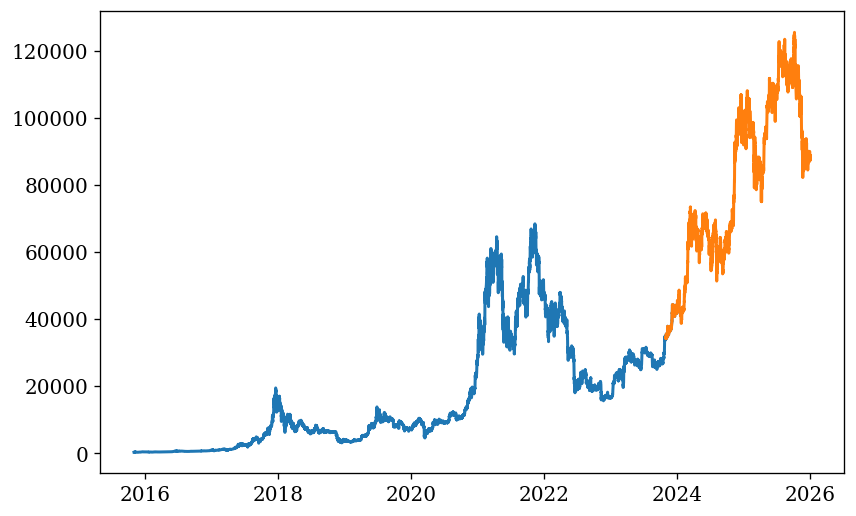

In [4]:
plt.plot(data_train)
plt.plot(data_test)

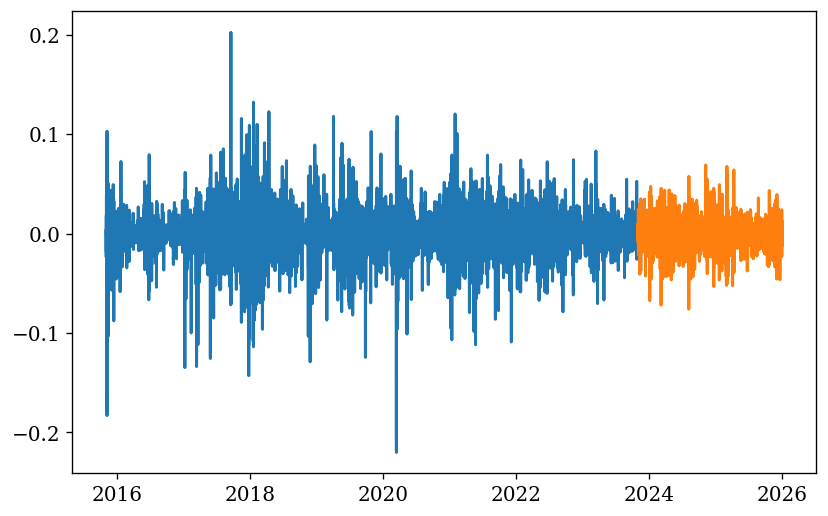

In [5]:
plt.plot(returns_train)
plt.plot(returns_test)

In [6]:
N = np.array(returns_train['2015-10-31':'2016-01-01']).shape[0]
L = np.array(returns_train).shape[0]
L_test = np.array(returns_test).shape[0]

#train-test split. Train: first 80% times, Test: last 20% (assuming stationarity)

init_train = N
final_train = L
init_test = N
final_test = L_test

sigma_roll_train = np.array([np.std(returns_train[i-N:i]) for i in range(N, returns_train.shape[0])])


sigma_roll_test = np.array([np.std(returns_test[i-N:i]) for i in range(N, returns_test.shape[0])])


scaled_returns_train = (np.array(returns_train)[init_train:final_train] / sigma_roll_train).reshape((1, -1))
scaled_returns_test = (np.array(returns_test)[init_test:final_test] / sigma_roll_test).reshape((1, -1))

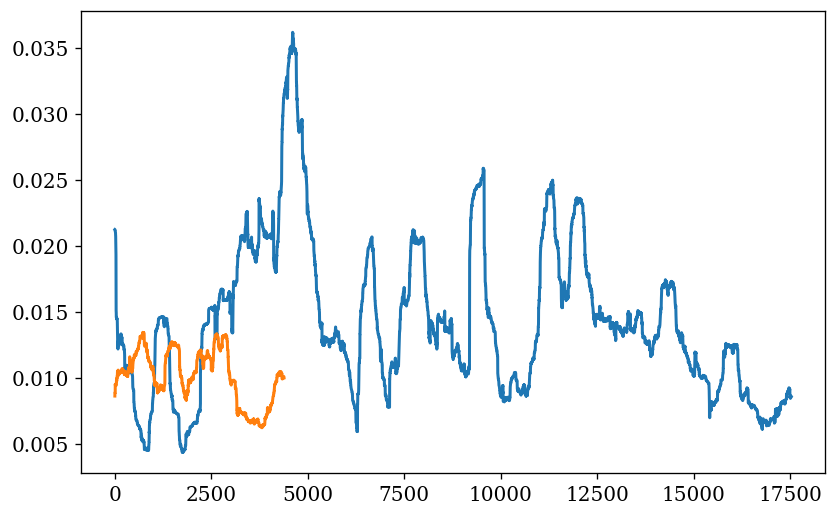

In [7]:
plt.plot(sigma_roll_train)
plt.plot(sigma_roll_test)

In [8]:
scaled_returns_train

array([[-0.09127658, -0.01414186,  0.05980632, ...,  1.10142601,
        -0.41206665,  0.37669229]], shape=(1, 17525))

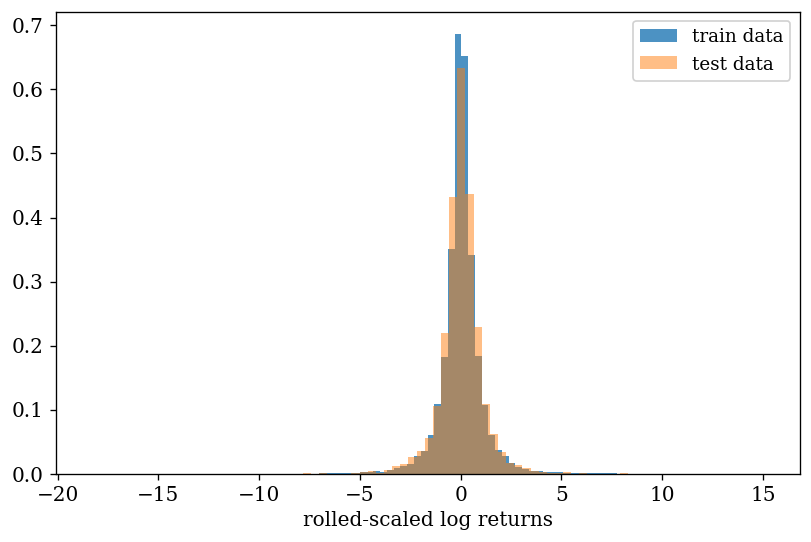

In [9]:
#plt.hist(returns, bins=100, density=True, label='full data')
plt.hist(scaled_returns_train[0, :], bins=100, density=True, alpha=0.8, label ='train data')
plt.hist(scaled_returns_test[0, :], bins=40, density=True, alpha=0.5, label ='test data')
plt.xlabel('rolled-scaled log returns')
plt.legend()


In [10]:
# Gaussian baseline of train data

mu = np.mean(scaled_returns_train[0, :])
sigma = np.std(scaled_returns_train[0, :])

mu_test = np.mean(scaled_returns_test[0, :])
sigma_test = np.std(scaled_returns_test[0, :])

from scipy.stats import norm

train_baseline_ll = np.mean(norm.logpdf(scaled_returns_train[0, :], loc=mu, scale=sigma))
test_baseline_ll = np.mean(norm.logpdf(scaled_returns_test[0, :], loc=mu_test, scale=sigma_test))

print(f"Baseline train: {train_baseline_ll:.4f} nats/step")
print(f"Baseline test:  {test_baseline_ll:.4f} nats/step")


Baseline train: -1.4847 nats/step
Baseline test:  nan nats/step


In [12]:
### Training Hidden Markov model with Student's emissions and three regimes

err = []
HMM_list = []
N_cycles = 10  # number of iterations to escape local minima
final_err = []

for i in range(N_cycles):
    
    pi = np.random.rand((3))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [0, np.random.uniform(0.1, 1)],  
    [0, np.random.uniform(0.1, 1)],
    [0, np.random.uniform(0.1, 1)]
    ])
    
    emission = emission_model.Gaussian_Emission(3, scaled_returns_train, params)
    HMM = hmm.Hmm(3, emission, pi, A=None, eps=1e-8)
    
    err.append(HMM.Baum_Welch(scaled_returns_train, data_test=scaled_returns_test, N_max=200))
    final_err.append(err[i][-1])
    
    HMM_list.append(HMM)

############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  logL =      -1.436241  |  ΔL/L = 100.000000% |  logL_test = -1.533388
Iteration    2  |  logL =      -1.289898  |  ΔL/L = 10.189355% |  logL_test = -1.341916
Iteration    3  |  logL =      -1.276922  |  ΔL/L = 1.005915% |  logL_test = -1.328965
Iteration    4  |  logL =      -1.269800  |  ΔL/L = 0.557728% |  logL_test = -1.320796
Iteration    5  |  logL =      -1.265239  |  ΔL/L = 0.359259% |  logL_test = -1.314788
Iteration    6  |  logL =      -1.261993  |  ΔL/L = 0.256515% |  logL_test = -1.310021
Iteration    7  |  logL =      -1.259566  |  ΔL/L = 0.192326% |  logL_test = -1.306120
Iteration    8  |  logL =      -1.257689  |  ΔL/L = 0.149029% |  logL_test = -1.302861
Iteration    9  |  logL =      -1.256179  |  ΔL/L = 0.120013% |

KeyboardInterrupt: 

IndexError: list index out of range

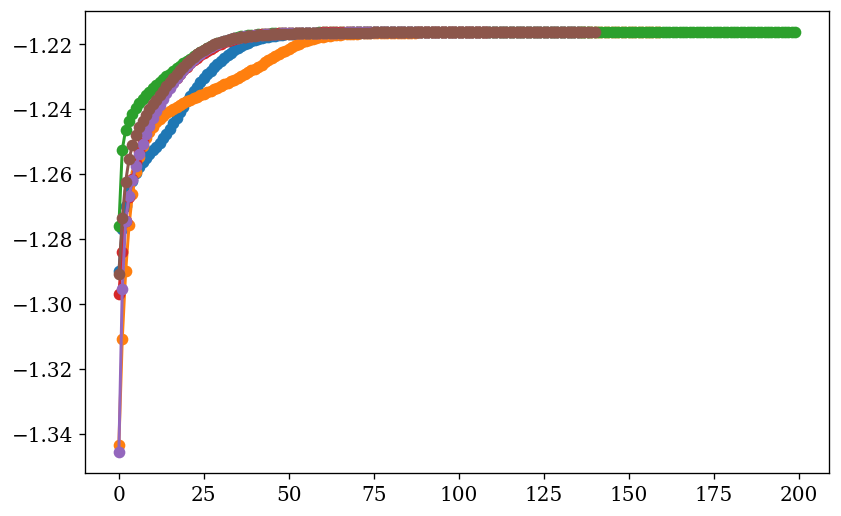

In [13]:
import matplotlib.pyplot as pltFalse

for i in range(N_cycles):
    
    plt.plot(err[i][1:], marker='o')

In [14]:
HMM_Gauss = HMM_list[np.argmax(np.array(final_err))]
HMM_Gauss.emission.params

array([[ 0.0147677 ,  0.31983045],
       [ 0.04600185,  0.97616239],
       [-0.06877831,  2.82445008]])

In [ ]:
### Training Hidden Markov model with Student's emissions and three regimes

err = []
HMM_list = []
N_cycles = 10  # number of iterations to escape local minima
final_err = []

for i in range(N_cycles):
    
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [0, np.random.uniform(0.1, 1), 4],  # state 0
    [0, np.random.uniform(0.1, 1), 20],
    #[0, np.random.uniform(0.1, 1), 20]  # state 1
    
    ])
    
    emission = emission_model.Student_Emission(2, scaled_returns_train, params, params_to_optimize=[True, True, False])
    HMM = hmm.Hmm(2, emission, pi, A=None, eps=1e-8)
    
    err.append(HMM.Baum_Welch(scaled_returns_train, data_test=scaled_returns_test, N_max=200))
    final_err.append(err[i][-1])
    
    HMM_list.append(HMM)

############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  logL =      -1.390926  |  ΔL/L = 100.000000% |  logL_test = -1.479482
Iteration    2  |  logL =      -1.293391  |  ΔL/L = 7.012232% |  logL_test = -1.354310
Iteration    3  |  logL =      -1.287455  |  ΔL/L = 0.458978% |  logL_test = -1.348162
Iteration    4  |  logL =      -1.281792  |  ΔL/L = 0.439865% |  logL_test = -1.342424
Iteration    5  |  logL =      -1.276456  |  ΔL/L = 0.416266% |  logL_test = -1.336774
Iteration    6  |  logL =      -1.271367  |  ΔL/L = 0.398731% |  logL_test = -1.331106
Iteration    7  |  logL =      -1.266449  |  ΔL/L = 0.386823% |  logL_test = -1.325364
Iteration    8  |  logL =      -1.261694  |  ΔL/L = 0.375411% |  logL_test = -1.319601
Iteration    9  |  logL =      -1.257141  |  ΔL/L = 0.360842% | 

In [ ]:
HMM_Student = HMM_list[np.argmax(np.array(final_err))]
HMM_Student.emission.params

array([[4.51483660e-02, 9.18990506e-01, 4.00000000e+00],
       [1.51903085e-02, 3.43293279e-01, 2.00000000e+01]])

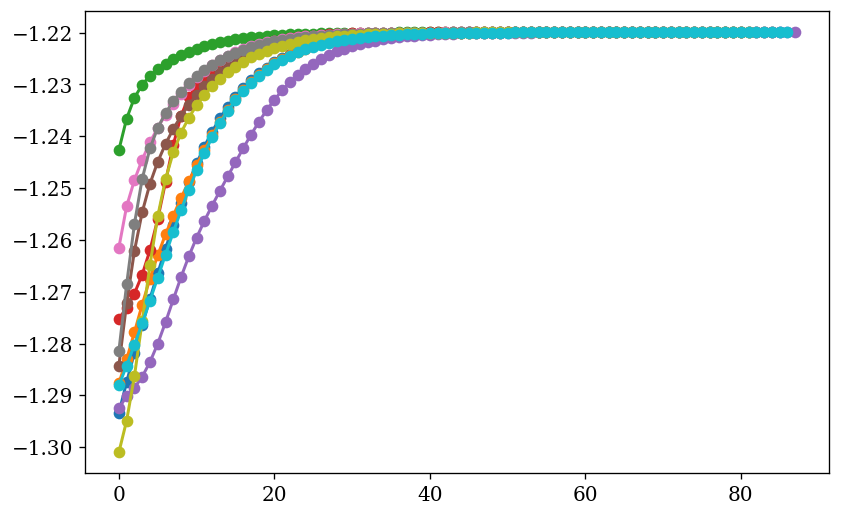

In [ ]:
import matplotlib.pyplot as pltFalse

for i in range(N_cycles):
    
    plt.plot(err[i][1:], marker='o')

In [ ]:
# saving the HMM to file

import pickle

with open('HMM_btc_2021.pkl', 'wb') as f:
    pickle.dump(HMM, f)


In [ ]:
# no need to re run the training
import pickle

with open('HMM_btc_2021.pkl', 'rb') as f:
    HMM = pickle.load(f)

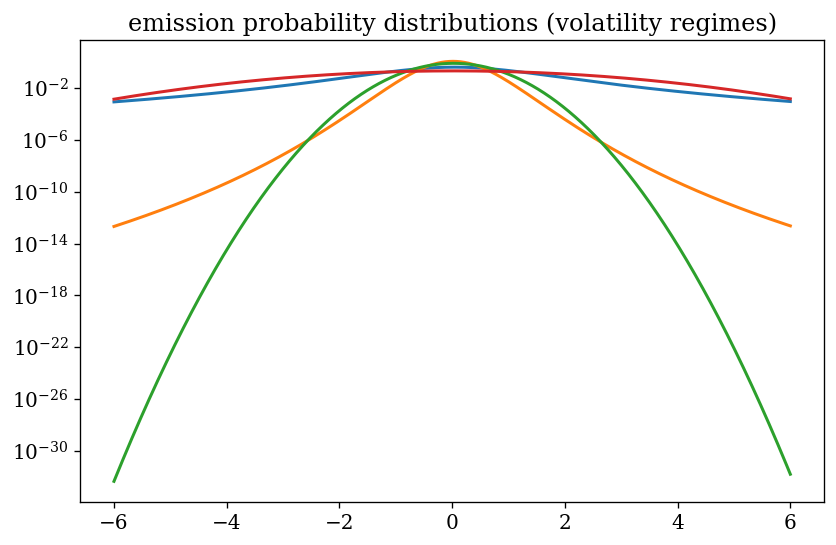

In [ ]:
from utils import Student, Gaussian
x = np.linspace(-6, 6, 10000)
plt.plot(x, Student(x, *HMM_Student.emission.params[0, :]))
plt.plot(x, Student(x, *HMM_Student.emission.params[1, :]))
#plt.plot(x, Student(x, *HMM_Student.emission.params[2, :]))

plt.plot(x, Gaussian(x, *HMM_Gauss.emission.params[0, :]))
plt.plot(x, Gaussian(x, *HMM_Gauss.emission.params[1, :]))
#plt.plot(x, Gaussian(x, *HMM_Gauss.emission.params[2, :]))
plt.title('emission probability distributions (volatility regimes)')
plt.yscale('log')

In [28]:
print(HMM.emission.params)
print(HMM.A)

[[0.0109758  2.00469779]
 [0.01691895 0.32820594]
 [0.03546407 0.67615489]]
[[0.69306627 0.10918414 0.19774959]
 [0.05123585 0.09157503 0.85718912]
 [0.11539783 0.60191892 0.28268324]]


In [24]:
# get the best sequence of hidden states given the model parameters from training
best_seqs = HMM.Viterbi(scaled_returns_train)

In [25]:
returns_train.shape
N
init_train

378

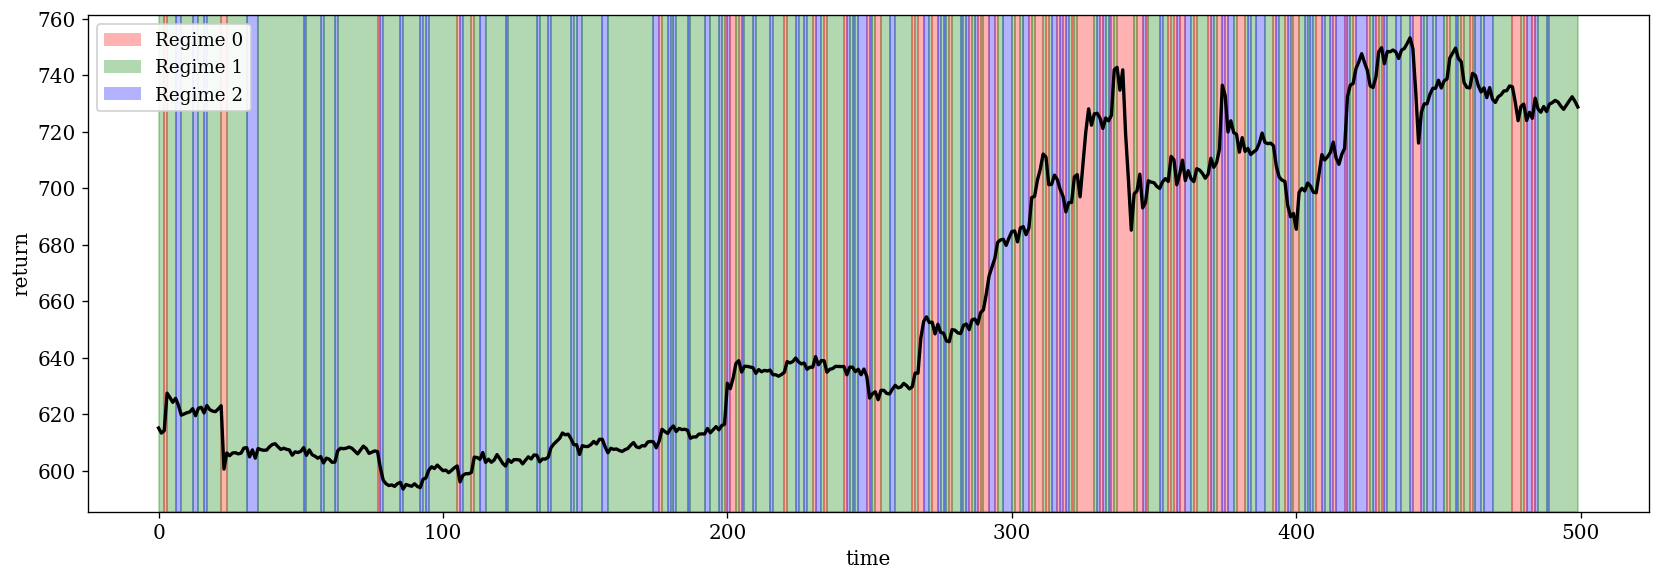

In [27]:
# plotting regimes and price 

dates = [i for i in range(500)]

plot_regimes(dates[:], np.array(data_train)[init_train+1500:init_train+2000], HMM.best_seqs[0, 1500:2000] , n_states=3, colors=['red', 'green', 'blue'])



In [29]:
# get the best sequence of hidden states given the model parameters from training
best_seqs = HMM.Viterbi(scaled_returns_test)

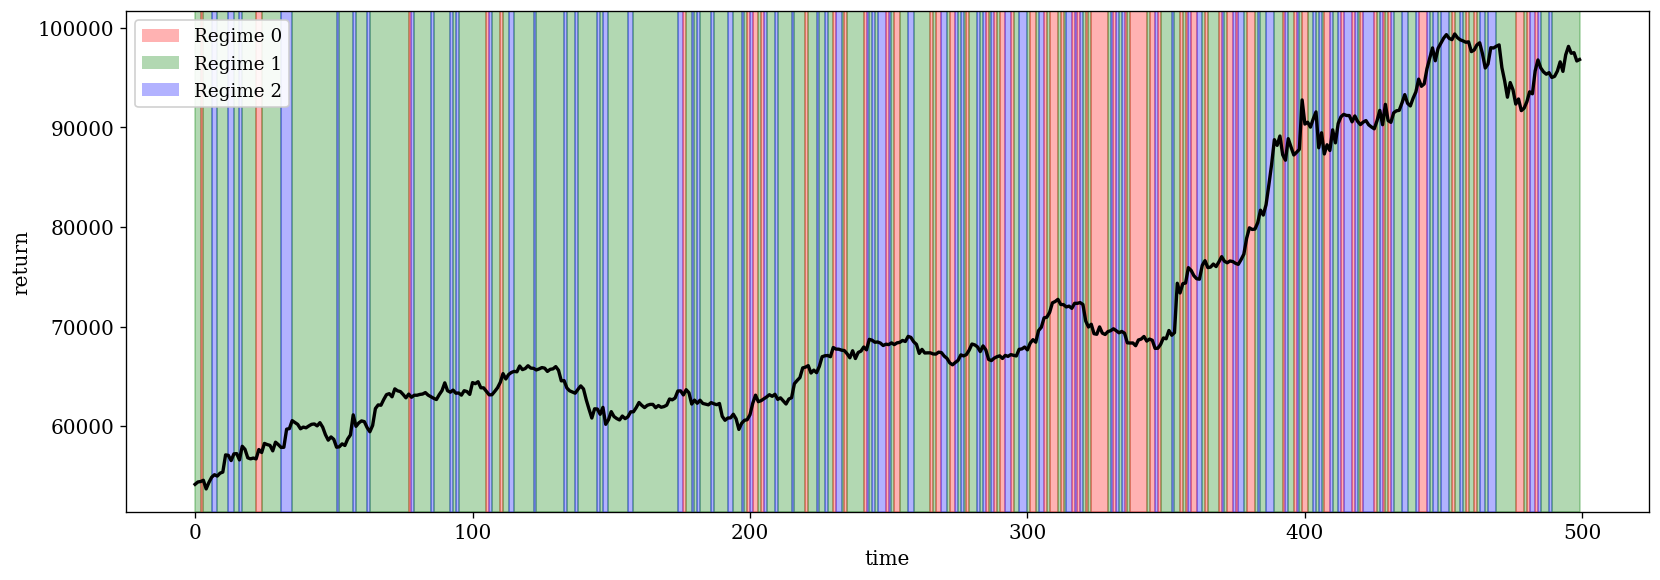

In [31]:
# plotting regimes and price 

dates = [i for i in range(500)]

plot_regimes(dates[:], np.array(data_test)[init_test+1500:init_test+2000], HMM.best_seqs[0, 1500:2000] , n_states=3, colors=['red', 'green', 'blue'])